# This Notebook is a trained model of Plant Identification

## EDA(Exploratory Data Analysis)

### Imports

In [3]:
import tensorflow as tf
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import os

### Loading Dataset

In [5]:
dataset = "./Dataset/PLANTS_DATASET"
classes = os.listdir(dataset)
print("Plant Classes:", classes)
print("Number of Classes:", len(classes))

Plant Classes: ['African Daisy', 'African Violet (Saintpaulia ionantha)', 'Aloe Vera', 'Alpine sea holly', 'Amarlillis', 'Amla', 'Amruta_Balli', 'Anthurium (Anthurium andraeanum)', 'Aquielegia', 'Arali', 'Areca Palm (Dypsis lutescens)', 'Ashoka', 'Ashwagandha', 'Asparagus Fern (Asparagus setaceus)', 'Astrantia major', 'Avacado', 'Balloon Flower', 'Bamboo', 'Basale', 'Begonia (Begonia spp.)', 'Betel', 'Betel_Nut', 'Bird of Paradise (Strelitzia reginae)', 'Birds Nest Fern (Asplenium nidus)', 'Black eyed susan', 'Blackberry lily', 'blooming globe', 'Boston Fern (Nephrolepis exaltata)', 'Brahmi', 'Buttercup', 'Calathea', 'Calendula', 'California poppy', 'Calla lily', 'Camellia', 'Canna lily', 'Canterbury bells', 'Cast Iron Plant (Aspidistra elatior)', 'Castor', 'Cattleya orchid', 'Celosia', 'Champa', 'Chinese evergreen (Aglaonema)', 'Chinese Lantern', 'Chinese Money Plant (Pilea peperomioides)', 'Christmas Cactus (Schlumbergera bridgesii)', 'Chrysanthemum', 'Clematis', 'Coltsfoot', 'Columb

In [6]:
data = []
for plant in classes:
    plant_path = os.path.join(dataset,plant)

    if os.path.isdir(plant_path):
        images = os.listdir(plant_path)
        data.append([plant,len(images)])

df = pd.DataFrame(data, columns=["Plant Name","Image Count"])
print(df)

                                Plant Name  Image Count
0                            African Daisy           51
1    African Violet (Saintpaulia ionantha)          337
2                                Aloe Vera          252
3                         Alpine sea holly           33
4                               Amarlillis           59
..                                     ...          ...
181                           Wood Anemone           46
182                             Wood_sorel          136
183                       Yellow Flag Iris           38
184                                  Yucca           66
185      ZZ Plant (Zamioculcas zamiifolia)          438

[186 rows x 2 columns]


### Distribution of number of images per plant

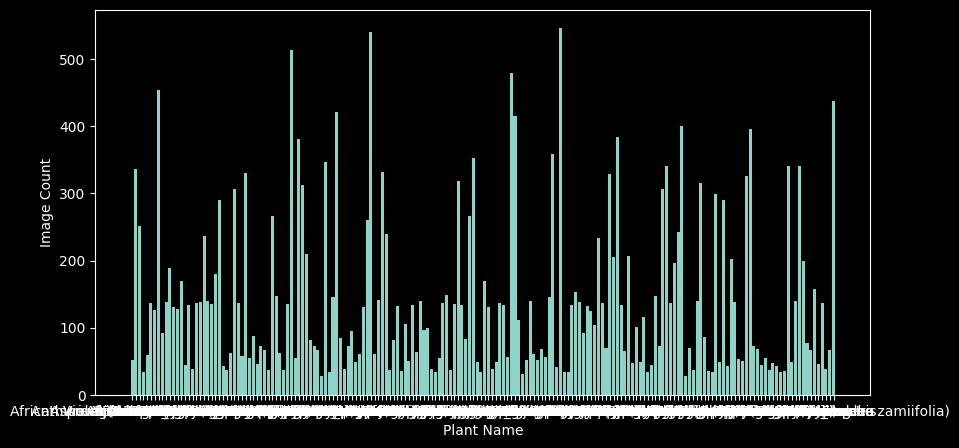

In [7]:
plt.figure(figsize=(10,5))
plt.bar(df["Plant Name"],df["Image Count"])
plt.xlabel("Plant Name")
plt.ylabel("Image Count")
plt.show()

### Checking Image shapes

In [8]:
sizes = []
for plant in classes:
    plant_path = os.path.join(dataset,plant)
    images = os.listdir(plant_path)

    for img_name in images[:5]:
        img_path = os.path.join(plant_path,img_name)
        img = cv2.imread(img_path)

        if img is not None:
            sizes.append(img.shape)

print("Sample Image Sizes", sizes[:10])

Sample Image Sizes [(500, 750, 3), (500, 624, 3), (626, 500, 3), (500, 625, 3), (500, 631, 3), (948, 1300, 3), (709, 1000, 3), (1229, 1614, 3), (2048, 1677, 3), (450, 600, 3)]


## EfficientNet Model Implementation

### Imports

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

### Hyperparameters

In [10]:
IMG_SIZE = 224 # EfficientNetB0 default size
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(classes)

### Data Preparation

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print("Number of training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Number of validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 26471 files belonging to 186 classes.
Using 21177 files for training.
Found 26471 files belonging to 186 classes.
Using 5294 files for validation.
Number of training batches: 662
Number of validation batches: 166


### Data Augmentation

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])

### Building EfficientNet Model

In [13]:
def build_efficientnet_model(num_classes):
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    base_model = EfficientNetB0(include_top=False, input_tensor=x, weights="imagenet")

    base_model.trainable = False

    x = GlobalAveragePooling2D(name="avg_pool")(base_model.output)
    x = BatchNormalization()(x)
    x = Dropout(0.3, name="top_dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="pred")(x)

    model = Model(inputs, outputs, name="EfficientNet_PlantID")

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

    return model


model = build_efficientnet_model(NUM_CLASSES)
model.summary()

Model: "EfficientNet_PlantID"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,292,957 (16.38 MB)

 Trainable params: 240,826 (940.73 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Removing Images which are other than RGB

In [14]:
from PIL import Image
import os

issues = []

for class_name in os.listdir(dataset):
    class_path = os.path.join(dataset, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            channels = len(img.getbands())
            if channels != 3:
                issues.append((fpath, img.mode, channels))
        except Exception as e:
            issues.append((fpath, "CORRUPT", str(e)))

print(f"Found {len(issues)} problematic files:\n")
for path, mode, ch in issues:
    print(f"  {mode:>6} ({ch} ch) — {path}")

Found 0 problematic files:



In [15]:
def preprocessing_image(image_path, label):
    image= tf.io.read_file(img_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None,None,3])
    image = tf.image.resize(image,[224,224])
    image = tf.cast(image,tf.float32)
    return image, label

### Training the model

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Starting training...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

Starting training...
Epoch 1/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 1103s 2s/step - accuracy: 0.4638 - loss: 2.2972 - val_accuracy: 0.6934 - val_loss: 1.1236
Epoch 2/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 1111s 2s/step - accuracy: 0.6748 - loss: 1.2137 - val_accuracy: 0.7378 - val_loss: 0.9438
Epoch 3/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 976s 1s/step - accuracy: 0.7207 - loss: 1.0309 - val_accuracy: 0.7552 - val_loss: 0.8748
Epoch 4/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 1009s 2s/step - accuracy: 0.7412 - loss: 0.9250 - val_accuracy: 0.7662 - val_loss: 0.8512
Epoch 5/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 1095s 2s/step - accuracy: 0.7611 - loss: 0.8554 - val_accuracy: 0.7730 - val_loss: 0.8143
Epoch 6/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 895s 1s/step - accuracy: 0.7674 - loss: 0.8298 - val_accuracy: 0.7886 - val_loss: 0.7793
Epoch 7/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 770s 1s/step - accuracy: 0.7753 - loss: 0.8018 - val_accuracy: 0.7837 - val_loss: 0.7806
Epoch 8/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 830s 1s/step - accuracy: 0.7753 

### Final training and validation accuracy & training and validation loss

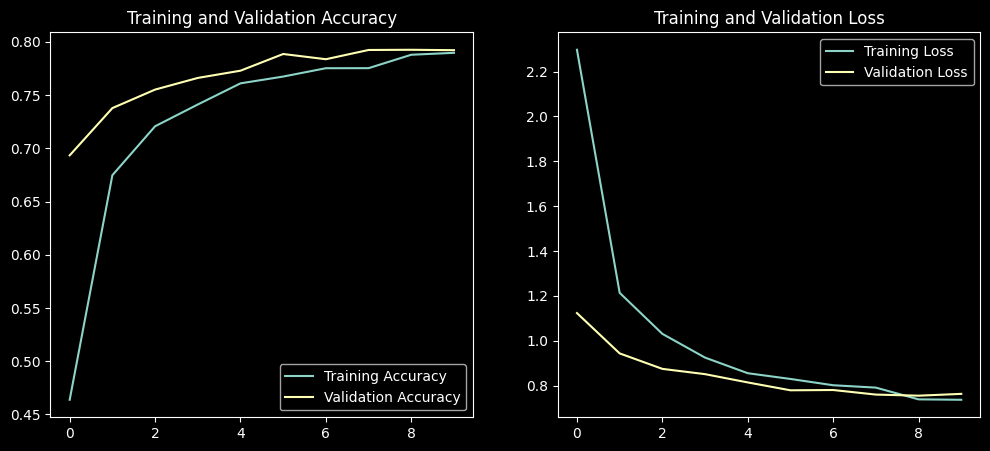

In [17]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

if 'history' in locals():
    plot_history(history)

## Saving the model

In [18]:
model.save("./plant_efficientnet_model.keras")
print("Model saved!")

Model saved!
